# Twitter Sentiment Analysis with NLP
## 1 Exploring dataset

#### 1.1 Load dataset

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import nltk

df = pd.read_csv('data/twitter.csv', encoding='utf-8')


#### 1.2 dataset info

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31962 entries, 0 to 31961
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      31962 non-null  int64 
 1   label   31962 non-null  int64 
 2   tweet   31962 non-null  object
dtypes: int64(2), object(1)
memory usage: 749.2+ KB


#### 1.3 dataset top 5 rows

In [3]:
df.head()

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


#### 1.4 Drop id column

In [4]:
df.drop(columns=['id'], inplace=True)
df.head()

,label,tweet
0,0,@user when a father is dysfunctional and is s...
1,0,@user @user thanks for #lyft credit i can't us...
2,0,bihday your majesty
3,0,#model i love u take with u all the time in ...
4,0,factsguide: society now #motivation


#### 1.5 Unique labels

2
label
0    29720
1     2242
Name: count, dtype: int64


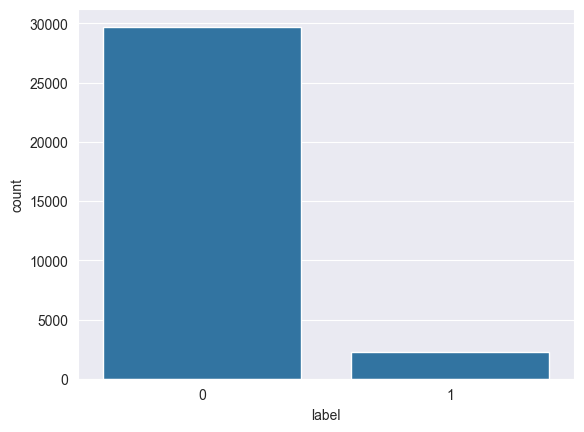

In [5]:
print(df['label'].nunique())
print(df['label'].value_counts())

# SNS plot to visualize
sns.countplot(x='label', data=df)
plt.show()

#### 1.6 Label Ratio

In [6]:
df['label'].value_counts(normalize=True)

label
0    0.929854
1    0.070146
Name: proportion, dtype: float64

**Note**: The label class is imbalanced

#### 1.6 Check tweet length

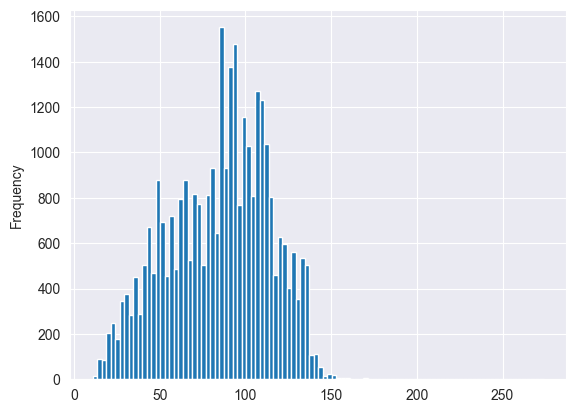

In [7]:
df['length'] = df['tweet'].apply(len)
df['length'].plot(bins=100, kind='hist')
plt.show()

## 2 Data cleanup
#### 2.1 Define preprocessor

In [8]:
import re
import html
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()


def ensure_stopwords():
    try:
        nltk.data.find('corpora/stopwords')
    except LookupError:
        nltk.download('stopwords')

def ensure_wordnet():
    try:
        nltk.data.find('corpora/wordnet')
    except LookupError:
        nltk.download('wordnet')

ensure_stopwords()
ensure_wordnet()

stop_words = set(stopwords.words('english'))

def preprocessor(text):
    # Remove HTML tags
    text = html.unescape(text)
    text = re.sub(r'<[^>]*>', '', text)

    # Remove mentions
    text = re.sub(r'@\w+', '', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Handle hashtags
    text = re.sub(r'#(\w+)', r'\1', text)

    # Extract Emoticons
    emoticons = re.findall(r'(?::|;|=)(?:-)?(?:\)|\(|D|P)', text)

    # Normalize text
    text = text.lower()
    text = re.sub(r'[\W]+', ' ', text)

    # Remove non-ASCII
    text = re.sub(r'[^\x00-\x7F]+', '', text)

    # Remove emoticons
    text = text + ' ' + ' '.join(emoticons).replace('-', '')

    # Remove stopwords
    tokens = [w for w in text.split() if w not in stop_words]

    tokens = [w for w in tokens if w.isalnum()]
    tokens = [lemmatizer.lemmatize(w) for w in tokens]

    return ' '.join(tokens)

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\durlo\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


#### 2.2 Test preprocessor

In [9]:
text =  'In 1974, the teenager Martha Moxley (Maggie Grace) moves to the high-class area of Belle Haven, Greenwich, Connecticut. On the Mischief Night, eve of Halloween, she was murdered in the backyard of her house and her murder remained unsolved. Twenty-two years later, the writer Mark Fuhrman (Christopher Meloni), who is a former LA detective that has fallen in disgrace for perjury in O.J. Simpson trial and moved to Idaho, decides to investigate the case with his partner Stephen Weeks (Andrew Mitchell) with the purpose of writing a book. The locals squirm and do not welcome them, but with the support of the retired detective Steve Carroll (Robert Forster) that was in charge of the investigation in the 70\'s, they discover the criminal and a net of power and money to cover the murder.<br /><br />"Murder in Greenwich" is a good TV movie, with the true story of a murder of a fifteen years old girl that was committed by a wealthy teenager whose mother was a Kennedy. The powerful and rich family…<'

cleaned_text = preprocessor(text)
print(cleaned_text)

1974 teenager martha moxley maggie grace move high class area belle greenwich connecticut mischief night eve halloween murdered backyard house murder remained unsolved twenty two year later writer mark fuhrman christopher meloni former la detective fallen disgrace perjury j simpson trial moved idaho decides investigate case partner stephen week andrew mitchell purpose writing book local squirm welcome support retired detective steve carroll robert forster charge investigation 70 discover criminal net power money cover murder murder greenwich good tv movie true story murder fifteen year old girl committed wealthy teenager whose mother kennedy powerful rich family


Test preprocessor on a Tweet

In [10]:
row = df.loc[df['length'].idxmax()]

print(row['tweet'])

cleaned_text = preprocessor(row['tweet'])
print(cleaned_text)

 @user lmfao pathetic #soit   #growup #funny #noonethere #iknowwhoitis ðððððððððððð¤ð¤ð¤ð¤ð¤ð¤ð¤ð¤ð¤ð¤ð¤ð¤ð±ð±ð¤ð¤ð±ð¤ð¤ð¤ð¤ð¤ð¤ð¤ð¤ð¤ð¤ð¤ð¤ð¤ð¤ð¤ðððððððâ¦
lmfao pathetic soit growup funny noonethere iknowwhoitis


#### 2.3 Apply preprocessor

In [11]:
df['tweet_raw'] = df['tweet']
df['tweet'] = df['tweet'].apply(preprocessor)
print(df.loc[df['length'].idxmax()]['tweet'])

lmfao pathetic soit growup funny noonethere iknowwhoitis


## 3 Sampling and dataset split
#### 3.1 Sampling

In [12]:
def get_sampled_df(df, n_total, ratio, min_words=10, replace: bool = False):
    # keep only tweets with at least min_words tokens
    df = df[df["tweet"].astype(str).str.split().str.len() >= min_words]

    n_class1 = int(n_total * ratio)
    n_class0 = n_total - n_class1

    df_class0 = df[df['label'] == 0].sample(
        n=n_class0, random_state=42, replace=replace
    )
    df_class1 = df[df['label'] == 1].sample(
        n=n_class1,
        random_state=42,
        replace=replace
    )

    df_sampled = pd.concat([df_class0, df_class1]).sample(
        frac=1, random_state=42
    ).reset_index(drop=True)

    return df_sampled




# from imblearn.over_sampling import SMOTE
# from sklearn.feature_extraction.text import TfidfVectorizer
#
# vectorizer = TfidfVectorizer()
# X = vectorizer.fit_transform(df['tweet'])
# y = df['label']
#
# smote = SMOTE()
# X_res, y_res = smote.fit_resample(X, y)
#
# y_res.value_counts(normalize=True)

#### 3.1 Train test data split

In [13]:
from sklearn.model_selection import train_test_split

# Sample dataset since label1 is minority
df_sampled = get_sampled_df(df, 3000, 0.3, min_words=15, replace=True)
df_sampled['label'].value_counts(normalize=True)

# X = df['tweet']
# y = df['label']

X = df_sampled['tweet']
y = df_sampled['label']

print(X.head())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)


0    dis hw broadband work lucknow t0 work t1 t5 do...
1    newjersey polar bear climb racing angry polar ...
2    happy bihday day 23 lebron miley jordan im bih...
3    humble never think better anyone else dust unt...
4    lol pasty cake telling rockette quit b c choic...
Name: tweet, dtype: object


## 5 Topic Modeling
#### 5.0 Define coherence evaluation method

In [14]:
import gensim.corpora as corpora
from gensim.models.coherencemodel import CoherenceModel


def print_topic_coherence(
    model,
    documents,
    vectorizer=None,
    model_type="auto",
    coherence="c_v",
    top_n_words=10,
    max_topics=None,
    exclude_outlier=True
):
    # Convert documents to list of strings
    documents = [str(doc) for doc in documents]

    # Auto-detect model type
    if model_type == "auto":
        if hasattr(model, "get_topics"):
            model_type = "bertopic"
        elif hasattr(model, "components_"):
            model_type = "lda"
        else:
            raise ValueError("Could not detect model type. Use model_type='bertopic' or model_type='lda'.")

    if model_type == "bertopic":
        cleaned_docs = model._preprocess_text(documents)

        vectorizer = model.vectorizer_model
        analyzer = vectorizer.build_analyzer()

        tokens = [analyzer(doc) for doc in cleaned_docs]

        topics = model.get_topics().copy()
        if exclude_outlier:
          topics.pop(-1, None)

        topic_words = []

        for topic_id, words_scores in topics.items():
            if exclude_outlier and topic_id == -1:
                continue

            words = [
                word
                for word, score in words_scores[:top_n_words]
                if word != ""
            ]

            if words:
                topic_words.append(words)

            if max_topics is not None and len(topic_words) >= max_topics:
                break

    elif model_type == "lda":
        if vectorizer is None:
            raise ValueError("For sklearn LDA, you must pass the fitted CountVectorizer as vectorizer.")

        analyzer = vectorizer.build_analyzer()
        tokens = [analyzer(doc) for doc in documents]

        feature_names = vectorizer.get_feature_names_out()

        topic_words = []

        for topic in model.components_:
            top_word_indices = topic.argsort()[-top_n_words:][::-1]
            words = [feature_names[i] for i in top_word_indices]
            topic_words.append(words)

            if max_topics is not None and len(topic_words) >= max_topics:
                break

    else:
        raise ValueError("model_type must be 'auto', 'bertopic', or 'lda'.")

    dictionary = corpora.Dictionary(tokens)
    corpus = [dictionary.doc2bow(token) for token in tokens]

    coherence_model = CoherenceModel(
        topics=topic_words,
        texts=tokens,
        corpus=corpus,
        dictionary=dictionary,
        coherence=coherence
    )

    coherence_score = coherence_model.get_coherence()

    print(f"Model type: {model_type}")
    print(f"Number of topics evaluated: {len(topic_words)}")
    print(f"Top words per topic: {top_n_words}")
    print(f"Coherence Score ({coherence}): {coherence_score}")

    return coherence_score

def save_topic_model_results_to_csv(results, output_path, model_type="lda"):
    rows = []

    for i, result in enumerate(results):

        row = {
            "model_type": model_type,
            "run_id": i
        }

        # Dictionary-based results
        if isinstance(result, dict):
            row["n_topics"] = result.get("n_topics")
            row["coherence"] = result.get("coherence")
            row["outlier_percentage"] = result.get("outlier_percentage", np.nan)

            x_topics = (
                result.get("X_topics")
                if "X_topics" in result
                else result.get("topics")
            )

        if X_topics is None:
            raise ValueError("X_topics must not be None.")

        # Store X_topics/topics safely as a compact string
        if x_topics is not None:
            try:
                x_topics_array = np.asarray(x_topics)

                row["x_topics_shape"] = str(x_topics_array.shape)

                # Do not save huge document-topic matrices directly in full
                if x_topics_array.ndim == 2:
                    dominant_topics = x_topics_array.argmax(axis=1)
                    row["dominant_topics"] = ",".join(map(str, dominant_topics))
                else:
                    row["dominant_topics"] = ",".join(map(str, x_topics_array))

            except Exception:
                row["x_topics_shape"] = None
                row["dominant_topics"] = str(x_topics)
        else:
            row["x_topics_shape"] = None
            row["dominant_topics"] = None

        rows.append(row)

    df_results = pd.DataFrame(rows)
    df_results.to_csv(output_path, index=False)

    print(f"Saved {len(df_results)} {model_type} results to {output_path}")

    return df_results

#### 5.1 LDA

In [15]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

lda_results = []

for n_topics in [5, 8, 10, 12, 15, 20]:

    vectorizer = CountVectorizer(
        stop_words='english',
        min_df=3,
        max_df=0.8,
        max_features=10000,
        ngram_range=(1, 2)
    )

    X_vec = vectorizer.fit_transform(X)

    lda = LatentDirichletAllocation(
        n_components=n_topics,
        random_state=42,
        learning_method='batch',
        max_iter=20,
        doc_topic_prior=0.1,
        topic_word_prior=0.01
    )

    X_topics = lda.fit_transform(X_vec)

    coherence = print_topic_coherence(
        lda,
        X,
        vectorizer=vectorizer,
        model_type="lda",
        top_n_words=10
    )

    lda_results.append({
        "n_topics": n_topics,
        "lda": lda,
        "vectorizer": vectorizer,
        "X_vec": X_vec,
        "X_topics": X_topics,
        "coherence": coherence
    })

best_result = max(lda_results, key=lambda x: x["coherence"])

best_lda = best_result["lda"]
best_vectorizer = best_result["vectorizer"]
best_X_vec = best_result["X_vec"]
best_X_topics = best_result["X_topics"]
best_n_topics = best_result["n_topics"]
best_coherence = best_result["coherence"]

print("Best number of topics:", best_n_topics)
print("Best coherence:", best_coherence)

save_topic_model_results_to_csv(
    lda_results,
    "output/lda_results.csv",
    model_type="lda"
)

X_topics = best_X_topics

Model type: lda
Number of topics evaluated: 5
Top words per topic: 10
Coherence Score (c_v): 0.5021380935564929
Model type: lda
Number of topics evaluated: 8
Top words per topic: 10
Coherence Score (c_v): 0.5891407110203879
Model type: lda
Number of topics evaluated: 10
Top words per topic: 10
Coherence Score (c_v): 0.6378538969376417
Model type: lda
Number of topics evaluated: 12
Top words per topic: 10
Coherence Score (c_v): 0.6716258913106009
Model type: lda
Number of topics evaluated: 15
Top words per topic: 10
Coherence Score (c_v): 0.837835830385829
Model type: lda
Number of topics evaluated: 20
Top words per topic: 10
Coherence Score (c_v): 0.8344146565725475
Best number of topics: 15
Best coherence: 0.837835830385829
Saved 6 lda results to output/lda_results.csv


#### 5.1.1 Print/View topics

In [16]:
def print_topics(model, vectorizer, n_top_words=5):
    feature_names = vectorizer.get_feature_names_out()

    for topic_idx, topic in enumerate(model.components_):
        top_word_indices = topic.argsort()[-n_top_words:][::-1]
        top_words = [feature_names[i] for i in top_word_indices]

        print(f"Topic {topic_idx + 1}:")
        print(" ".join(top_words))


#### 5.1.2 Print LDA

In [17]:
print_topics(best_lda, vectorizer, n_top_words=5)
topic_cat1 = X_topics[:, 2].argsort()[::-1]


for iter_idx, topic_idx in enumerate(topic_cat1[:3]):
    print('\nTopic #%d:' % (iter_idx + 1))
    print(df['tweet'][topic_idx][:300], '...')

Topic 1:
bear polar bear polar bear climb climb
Topic 2:
la make ur idea mom
Topic 3:
na horny wet kinky naughty
Topic 4:
japan bbc new group puppet
Topic 5:
happy like white year people
Topic 6:
let 30 mon pm justice
Topic 7:
blog blog silver silver gold silver gold
Topic 8:
poetry trump follow family win
Topic 9:
yr lie came clean left
Topic 10:
ppl look event ur service
Topic 11:
new tweet order commercial kid
Topic 12:
06 lol comedy choice happy
Topic 13:
pig pay going release monster
Topic 14:
im bc bc im asian attracted
Topic 15:
trump obama michelle chair male

Topic #1:
mood anything depression strike depressed broken ...

Topic #2:
might libtard libtard sjw liberal politics ...

Topic #3:
bb18 gonna suck sweaty ball summer tg bbuk good cast 2 house secret task grodner kass think outside box ...


#### 5.1.3 Visualise topics

In [18]:
!pip install pyLDAvis
import pyLDAvis
import pyLDAvis.lda_model

pyLDAvis.enable_notebook()

vis = pyLDAvis.lda_model.prepare(
    best_lda,
    best_X_vec,
    best_vectorizer
)

vis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0      0.184572 -0.235447       1        1  11.406193
8     -0.094903 -0.135159       2        1   7.899808
13    -0.135065 -0.102441       3        1   7.610888
10     0.295151  0.044879       4        1   7.500006
2      0.066029  0.153094       5        1   7.273347
7      0.108712  0.099070       6        1   7.066971
14     0.116664  0.180462       7        1   6.718322
6     -0.017950 -0.131488       8        1   6.673484
5     -0.124826  0.133341       9        1   6.527520
1     -0.137941  0.018516      10        1   5.775595
4     -0.106859  0.041475      11        1   5.644958
11    -0.101694  0.008355      12        1   5.545517
12    -0.085842  0.149245      13        1   5.040950
3      0.029125 -0.097645      14        1   4.761748
9      0.004828 -0.126257      15        1   4.554691, topic_info=            Term        Freq       Total Category  logprob  loglift
4849       polar  596.000000  596.000000  Default  30.0000  30.0000
4850  polar bear  596.000000  596.000000  Default  29.0000  29.0000
841         bear  596.000000  596.000000  Default  28.0000  28.0000
4331         new  764.000000  764.000000  Default  27.0000  27.0000
842   bear climb  397.000000  397.000000  Default  26.0000  26.0000
...          ...         ...         ...      ...      ...      ...
4918         ppl   36.030979  125.364489  Topic15  -4.5434   1.8422
3785        look   33.683226  137.403572  Topic15  -4.6108   1.6831
6558          ur   30.837672  123.788870  Topic15  -4.6991   1.6992
4759       place   26.053518  222.118455  Topic15  -4.8677   0.9460
2949        help   17.949486   72.041139  Topic15  -5.2403   1.6993

[633 rows x 6 columns], token_table=      Topic      Freq        Term
term                             
10        7  0.051092          06
10       12  0.953724          06
27        1  0.052437          10
27        2  0.104873          10
27        3  0.039327          10
...     ...       ...         ...
7077      2  0.761380          yr
7077      4  0.042299          yr
7077      5  0.155096          yr
7077      6  0.042299          yr
7079      2  0.991843  yr endless

[963 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 9, 14, 11, 3, 8, 15, 7, 6, 2, 5, 12, 13, 4, 10])

#### 5.2 BERTopic

In [19]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

def is_colab():
    try:
        import google.colab
        return True
    except ImportError:
        return False

if is_colab():
    !pip install bertopic
    !pip install sentence_transformers

In [20]:
from bertopic import BERTopic
import torch
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else None)

embedding_model = SentenceTransformer(
    "all-MiniLM-L6-v2",
    device="cuda" if torch.cuda.is_available() else "cpu"
)

vectorizers = [
    CountVectorizer(stop_words="english", min_df=1, max_df=0.95, ngram_range=(1, 1)),
    CountVectorizer(stop_words="english", min_df=1, max_df=0.95, ngram_range=(1, 2)),
    CountVectorizer(stop_words="english", min_df=2, max_df=0.9, ngram_range=(1, 2)),
    CountVectorizer(stop_words="english", min_df=3, max_df=0.9, ngram_range=(1, 2)),
]

results = []

for vectorizer in vectorizers:
    topic_model = BERTopic(
        embedding_model=embedding_model,
        vectorizer_model=vectorizer,
        language="english",
        calculate_probabilities=True,
        verbose=True
    )

    topics, probs = topic_model.fit_transform(X.tolist())

    coherence = print_topic_coherence(
        topic_model,
        X,
        model_type="bertopic",
        top_n_words=10
    )

    topic_info = topic_model.get_topic_info()
    n_topics = len(topic_info[topic_info["Topic"] != -1])

    outlier_count = topic_info.loc[topic_info["Topic"] == -1, "Count"].sum()
    outlier_percentage = outlier_count / len(X) * 100

    results.append({
        "vectorizer": vectorizer,
        "coherence": coherence,
        "n_topics": n_topics,
        "outlier_percentage": outlier_percentage,
        "topics": topics,
        "probs": probs,
        "topic_model": topic_model
    })

best_result = max(results, key=lambda x: x["coherence"])
best_vectorizer = best_result["vectorizer"]
best_coherence = best_result["coherence"]
best_n_topics = best_result["n_topics"]
best_outlier_percentage = best_result["outlier_percentage"]
topics = best_result["topics"]
probs = best_result["probs"]
topic_model = best_result["topic_model"]

print(f"Best coherence: {best_coherence:.2f}")
print(f"Best number of topics: {best_n_topics}")
print(f"Outlier percentage: {best_outlier_percentage:.2f}%")

save_topic_model_results_to_csv(
    results,
    "output/bertopic_results.csv",
    model_type="bertopic"
)

D:\PyCharmProjects\ICT606-Assignment2-TopicModelling-NLP\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Torch: 2.12.0+cu130
CUDA available: True
GPU: NVIDIA GeForce RTX 5070 Laptop GPU


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9929.29it/s]
2026-05-24 21:50:36,169 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 94/94 [00:00<00:00, 104.10it/s]
2026-05-24 21:50:37,084 - BERTopic - Embedding - Completed ✓
2026-05-24 21:50:37,084 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-24 21:50:49,771 - BERTopic - Dimensionality - Completed ✓
2026-05-24 21:50:49,773 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-24 21:50:50,641 - BERTopic - Cluster - Completed ✓
2026-05-24 21:50:50,649 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-24 21:50:50,699 - BERTopic - Representation - Completed ✓
2026-05-24 21:51:07,094 - BERTopic - Embedding - Transforming documents to embeddings.


Model type: bertopic
Number of topics evaluated: 112
Top words per topic: 10
Coherence Score (c_v): 0.7604851328756761


Batches: 100%|██████████| 94/94 [00:00<00:00, 122.03it/s]
2026-05-24 21:51:07,878 - BERTopic - Embedding - Completed ✓
2026-05-24 21:51:07,880 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-24 21:51:13,570 - BERTopic - Dimensionality - Completed ✓
2026-05-24 21:51:13,572 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-24 21:51:14,513 - BERTopic - Cluster - Completed ✓
2026-05-24 21:51:14,517 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-24 21:51:14,575 - BERTopic - Representation - Completed ✓
2026-05-24 21:51:31,139 - BERTopic - Embedding - Transforming documents to embeddings.


...

Batches: 100%|██████████| 94/94 [00:00<00:00, 122.01it/s]
2026-05-24 21:51:31,928 - BERTopic - Embedding - Completed ✓
2026-05-24 21:51:31,929 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-24 21:51:36,933 - BERTopic - Dimensionality - Completed ✓
2026-05-24 21:51:36,935 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-24 21:51:37,767 - BERTopic - Cluster - Completed ✓
2026-05-24 21:51:37,772 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-24 21:51:37,824 - BERTopic - Representation - Completed ✓
2026-05-24 21:51:54,208 - BERTopic - Embedding - Transforming documents to embeddings.


Model type: bertopic
Number of topics evaluated: 112
Top words per topic: 10
Coherence Score (c_v): 0.6120271361570289


Batches: 100%|██████████| 94/94 [00:00<00:00, 121.36it/s]
2026-05-24 21:51:54,989 - BERTopic - Embedding - Completed ✓
2026-05-24 21:51:54,989 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-24 21:52:00,072 - BERTopic - Dimensionality - Completed ✓
2026-05-24 21:52:00,074 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-24 21:52:00,961 - BERTopic - Cluster - Completed ✓
2026-05-24 21:52:00,965 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-24 21:52:01,013 - BERTopic - Representation - Completed ✓


Model type: bertopic
Number of topics evaluated: 112
Top words per topic: 10
Coherence Score (c_v): 0.5927910819334686
Best coherence: 0.86
Best number of topics: 112
Outlier percentage: 8.60%
Saved 4 bertopic results to output/bertopic_results.csv


,model_type,run_id,n_topics,coherence,outlier_percentage,x_topics_shape,dominant_topics
0,bertopic,0,112,0.760485,7.766667,"(3000,)","18,7,64,-1,3,-1,47,26,82,14,0,-1,45,-1,27,29,-..."
1,bertopic,1,112,0.856762,8.600000,"(3000,)","42,7,61,-1,2,-1,5,28,83,15,0,-1,45,-1,26,12,-1..."
2,bertopic,2,112,0.612027,7.733333,"(3000,)","45,3,78,4,2,15,54,25,80,13,0,-1,47,103,27,9,-1..."
3,bertopic,3,112,0.592791,7.633333,"(3000,)","69,9,76,6,3,31,54,26,81,14,0,-1,45,-1,5,28,-1,..."


#### 5.2.1 Extracting topics

In [21]:
freq = topic_model.get_topic_info(); freq.head(5)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,258,-1_truck_season_4wd_love,"[truck, season, 4wd, love, bear, polar bear, p...",[amazon rc nitro gas truck car 4wd via toyspot...
1,0,65,0_came clean_clarity_activist_activist realize,"[came clean, clarity, activist, activist reali...",[8 yr endless lie contempt left activist u rea...
2,1,56,1_ape_africa usa_billionaire chair_billionaire,"[ape, africa usa, billionaire chair, billionai...",[billionaire chair trump say hope obama dy mic...
3,2,49,2_asshat_asshat president_comedy weirdo_lol pasty,"[asshat, asshat president, comedy weirdo, lol ...",[lol pasty cake telling rockette quit b c choi...
4,3,46,3_gym_poetry_weightloss_stone,"[gym, poetry, weightloss, stone, fitness, vani...",[eat well feel swell health wealth love happin...


**Select the most frequent topic**

In [22]:
topic_model.get_topic(0)

[('came clean', np.float64(0.12535702427765086)),
 ('clarity', np.float64(0.12535702427765086)),
 ('activist', np.float64(0.12535702427765086)),
 ('activist realize', np.float64(0.12535702427765086)),
 ('clarity came', np.float64(0.12535702427765086)),
 ('realize clarity', np.float64(0.12535702427765086)),
 ('left activist', np.float64(0.12535702427765086)),
 ('lie contempt', np.float64(0.12535702427765086)),
 ('endless lie', np.float64(0.12535702427765086)),
 ('endless', np.float64(0.12535702427765086))]

#### 5.2.3 Visualisation

In [23]:
topic_model.visualize_topics()

#### 5.2.4 Visualise Topic Probabilities

In [24]:
topic_model.visualize_distribution(probs[200], min_probability=0.005)

#### 5.2.5 Visualise Topic Hierarchy

In [25]:
topic_model.visualize_hierarchy(top_n_topics=50)

#### 5.2.6 Visualise Terms

In [26]:
topic_model.visualize_barchart(top_n_topics=5)

#### 5.2.7 Visualise Topic Similarity

In [27]:
topic_model.visualize_heatmap(n_clusters=5, width=1000, height=1000)

#### 5.2.8 Visualise Term Score Decline

In [28]:
topic_model.visualize_term_rank()